## Importing Modules

In [1]:
import gzip
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.manifold import TSNE
import pandas as pd
import torchvision.models as models
import time
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

## Data Loading

In [2]:
# MNIST Dataset
train_data = datasets.MNIST(root=".", train=True, download=True)
test_data = datasets.MNIST(root=".", train=False, download=True)

x_train = train_data.data.numpy()
y_train = train_data.targets.numpy()
x_test = test_data.data.numpy()
y_test = test_data.targets.numpy()

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.12MB/s]


In [3]:
x_train_flat = x_train.reshape(len(x_train), -1)
x_test_flat = x_test.reshape(len(x_test), -1)
print(x_train_flat.shape)
print(x_test_flat.shape)

(60000, 784)
(10000, 784)


In [4]:
#Normalize the data from [0,255] to [0,1]
x_train_norm = x_train_flat.astype('float32') / 255.0
x_test_norm = x_test_flat.astype('float32') / 255.0

In [5]:
# Fashion MNIST Dataset
train_data_fashion = datasets.FashionMNIST(root=".", train=True, download=True)
test_data_fashion = datasets.FashionMNIST(root=".", train=False, download=True)

x_train_fashion = train_data_fashion.data.numpy()
y_train_fashion = train_data_fashion.targets.numpy()
x_test_fashion = test_data_fashion.data.numpy()
y_test_fashion = test_data_fashion.targets.numpy()

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.76MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.9MB/s]


In [6]:
x_test_fashion_flat = x_test_fashion.reshape(len(x_test_fashion), -1)
x_test_fashion_norm = x_test_fashion_flat.astype('float32') / 255
x_test_norm_tensor_fashion = torch.tensor(x_test_fashion_norm).float()
y_test_fashion_tensor = torch.tensor(y_test_fashion).long()

print(x_test_norm_tensor_fashion.shape)
print(y_test_fashion_tensor.shape)

x_train_fashion_flat = x_train_fashion.reshape(len(x_train_fashion), -1)
x_train_fashion_norm = x_train_fashion_flat.astype('float32') / 255
x_train_norm_tensor_fashion = torch.tensor(x_train_fashion_norm).float()
y_train_fashion_tensor = torch.tensor(y_train_fashion).long()

batch_size = 64
train_dataset_fashion = TensorDataset(x_train_norm_tensor_fashion, y_train_fashion_tensor)
train_loader_fashion = DataLoader(train_dataset_fashion, batch_size=batch_size, shuffle=True)

test_dataset_fashion = TensorDataset(x_test_norm_tensor_fashion, y_test_fashion_tensor)
test_loader_fashion = DataLoader(test_dataset_fashion, batch_size=batch_size, shuffle=True)

torch.Size([10000, 784])
torch.Size([10000])


## Baseline Models

In [7]:
#Baseline Models: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(x_train_norm, y_train)
y_pred_lr = lr_model.predict(x_test_norm)
lr_accuracy = accuracy_score(y_test, y_pred_lr)

In [8]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test Accuracy: 92.59%
Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.91      0.91      0.91      1010
           4       0.94      0.94      0.94       982
           5       0.90      0.87      0.88       892
           6       0.94      0.95      0.95       958
           7       0.93      0.92      0.93      1028
           8       0.88      0.88      0.88       974
           9       0.91      0.92      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



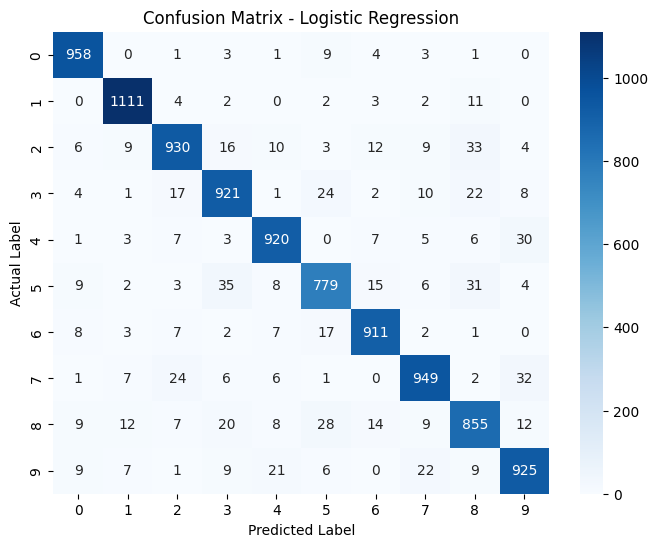

In [9]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [10]:
#Baseline Models: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=10)
rf_model.fit(x_train_norm, y_train)
y_pred_rf = rf_model.predict(x_test_norm)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

In [11]:
print(f"Random Forest Test Accuracy: {rf_accuracy * 100:.2f}%")
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Test Accuracy: 94.98%
Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       980
           1       0.98      0.99      0.98      1135
           2       0.94      0.96      0.95      1032
           3       0.93      0.95      0.94      1010
           4       0.94      0.96      0.95       982
           5       0.93      0.92      0.92       892
           6       0.97      0.95      0.96       958
           7       0.97      0.94      0.96      1028
           8       0.94      0.92      0.93       974
           9       0.95      0.92      0.93      1009

    accuracy                           0.95     10000
   macro avg       0.95      0.95      0.95     10000
weighted avg       0.95      0.95      0.95     10000



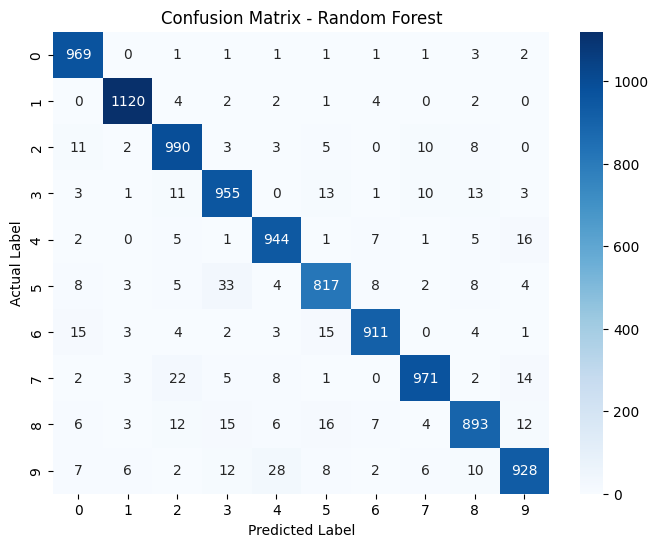

In [12]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## MLP


In [13]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(784,30)
        self.fc2 = nn.Linear(30,20)
        self.fc3 = nn.Linear(20,10)

    def forward(self, x):
        x = x.view(-1,784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

    def fit(self, train_loader, criterion, optimizer, num_epochs, device):
        print("Strating Training...")
        self.to(device)

        for epoch in range(num_epochs):
            start_time = time.time()
            self.train()
            running_loss = 0.0

            for inputs,labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss=criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss+=loss.item()

            epoch_time = time.time() - start_time
            avg_loss = running_loss/len(train_loader)
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")
        print("Finished Training!")


    def get_fc2_features(self, x):
        x = x.view(-1, 784)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x)) # These are the activations we want
        return x

    def evaluate(self, test_loader, device, class_names=None):
        self.to(device)
        self.eval()

        correct=0
        total=0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)
                _,predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

            accuracy = 100*correct/total
            print(f"Accuracy of the model on the {total} test images: {accuracy:.2f}%")

            report = classification_report(all_labels, all_preds, target_names=class_names)
            print(report)

            if class_names is None:
                tick_labels = sorted(list(np.unique(all_labels)))
            else:
                tick_labels = class_names
            cm = confusion_matrix(all_labels, all_preds)

            plt.figure(figsize=(10,8))
            sns.heatmap(cm, annot=True, fmt="d", xticklabels=tick_labels, yticklabels=tick_labels, cmap="Blues")
            plt.title("Confusion Matrix")
            plt.xlabel("Predicted Labels")
            plt.ylabel("Actual Labels")
            plt.show()

            return accuracy

    def plot_tsne(self, data_loader, device, num_classes=10):
        print("Generating t-SNE plot for fc2 activations...")
        self.to(device)
        self.eval()

        all_features = []
        all_labels = []

        with torch.no_grad():
            for inputs, labels in data_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                features = self.get_fc2_features(inputs)

                all_features.append(features.cpu().numpy())
                all_labels.append(labels.cpu().numpy())

        features_array = np.concatenate(all_features, axis=0)
        labels_array = np.concatenate(all_labels, axis=0)

        tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
        tsne_results = tsne.fit_transform(features_array)



        # Plot the results
        plt.figure(figsize=(12, 10))
        sns.scatterplot(
            x=tsne_results[:, 0],
            y=tsne_results[:, 1],
            hue=labels_array,
            palette=sns.color_palette("hls", num_classes),
            legend="full"
        )
        plt.title("t-SNE Visualization of 'fc2' Layer Activations")
        plt.xlabel("t-SNE Component 1")
        plt.ylabel("t-SNE Component 2")
        plt.legend(title="Class")
        plt.show()

In [14]:
#Dataset Loader for MLP
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x_train_norm_tensor = torch.from_numpy(x_train_norm).unsqueeze(1)
y_train_tensor = torch.from_numpy(y_train)
x_test_norm_tensor = torch.from_numpy(x_test_norm).unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test)

print(f"Training data shape: {x_train_norm_tensor.shape}")
print(f"Test data shape: {x_train_norm_tensor.shape}")

batch_size = 64
train_dataset = TensorDataset(x_train_norm_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(x_test_norm_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cuda
Training data shape: torch.Size([60000, 1, 784])
Test data shape: torch.Size([60000, 1, 784])


In [15]:
#Training the Model
model_MLP = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_MLP.parameters(), lr=0.001)

num_epochs = 10
model_MLP.fit(train_loader, criterion, optimizer, num_epochs, device)

Strating Training...
Epoch 1/10, Loss: 0.5061, Time: 2.65s
Epoch 2/10, Loss: 0.2387, Time: 1.82s
Epoch 3/10, Loss: 0.1920, Time: 1.80s
Epoch 4/10, Loss: 0.1650, Time: 1.80s
Epoch 5/10, Loss: 0.1466, Time: 1.80s
Epoch 6/10, Loss: 0.1325, Time: 1.79s
Epoch 7/10, Loss: 0.1208, Time: 2.12s
Epoch 8/10, Loss: 0.1119, Time: 1.87s
Epoch 9/10, Loss: 0.1046, Time: 1.78s
Epoch 10/10, Loss: 0.0970, Time: 1.79s
Finished Training!


Accuracy of the model on the 10000 test images: 96.30%
              precision    recall  f1-score   support

     digit 0       0.95      0.99      0.97       980
     digit 1       0.98      0.99      0.99      1135
     digit 2       0.96      0.96      0.96      1032
     digit 3       0.94      0.97      0.95      1010
     digit 4       0.97      0.97      0.97       982
     digit 5       0.98      0.93      0.95       892
     digit 6       0.96      0.98      0.97       958
     digit 7       0.98      0.96      0.97      1028
     digit 8       0.96      0.94      0.95       974
     digit 9       0.96      0.96      0.96      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



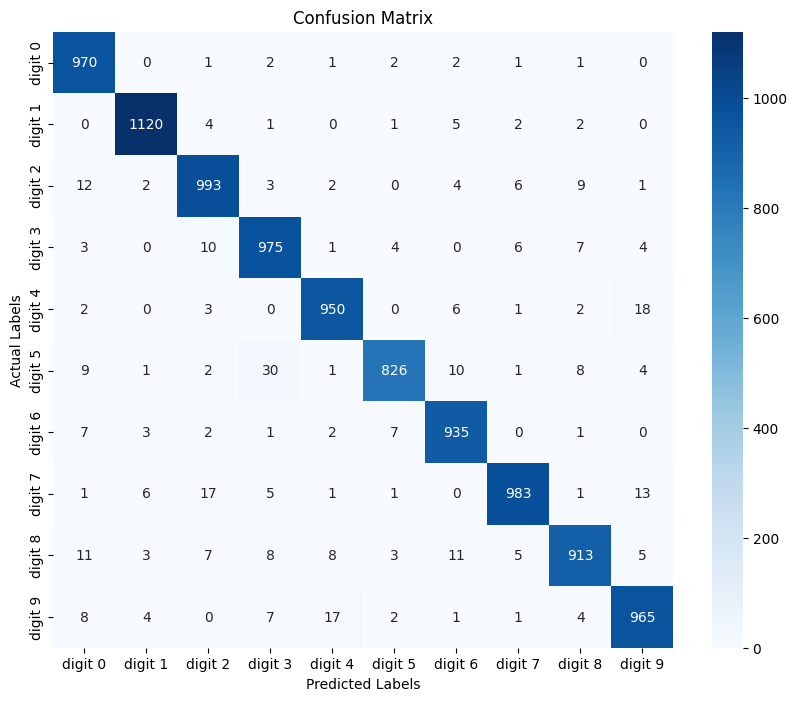

In [16]:
mnist_class_names = [f"digit {i}" for i in range(10)]
accuracy = model_MLP.evaluate(test_loader, device, class_names=mnist_class_names)

| Model | Accuracy | Avg F1-Score | Weighted Avg F1-Score | Weakest Class (Lowest Recall) |
| :--- | :--- | :--- | :--- | :--- |
| **MLP** | **96.52%** | **0.96** | **0.97** | Digit 8 (0.95), Digit 9 (0.95) |
| Random Forest | 94.69% | 0.95 | 0.95 | Digit 5 (0.91), Digit 8 (0.91), Digit 9 (0.91) |
| Logistic Regression | 92.59% | 0.92 | 0.93 | **Digit 5 (0.87)**, Digit 8 (0.88) |

Logistic Regression: Performed the worst (92.59%). It got totally confused by curvy digits, especially the 3-5-8 group.

Random Forest: Was better (94.69%), but it had the exact same weakness, getting stuck on the 3-5-8 confusion.

MLP: Performed well (96.52%), but its single biggest error was still confusing 5s with 3s. It also got faked out by 4s looking like 9s.

Generating t-SNE plot for fc2 activations...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


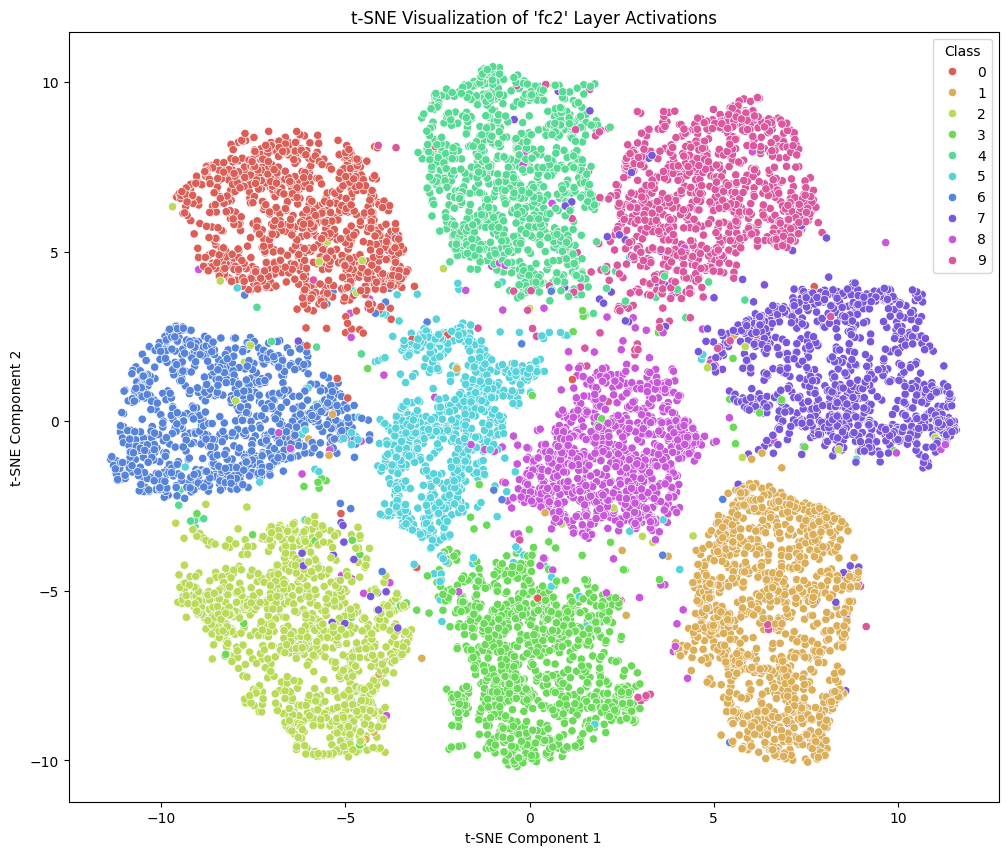

In [17]:
model_MLP.plot_tsne(test_loader, device)

Generating t-SNE plot for fc2 activations...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


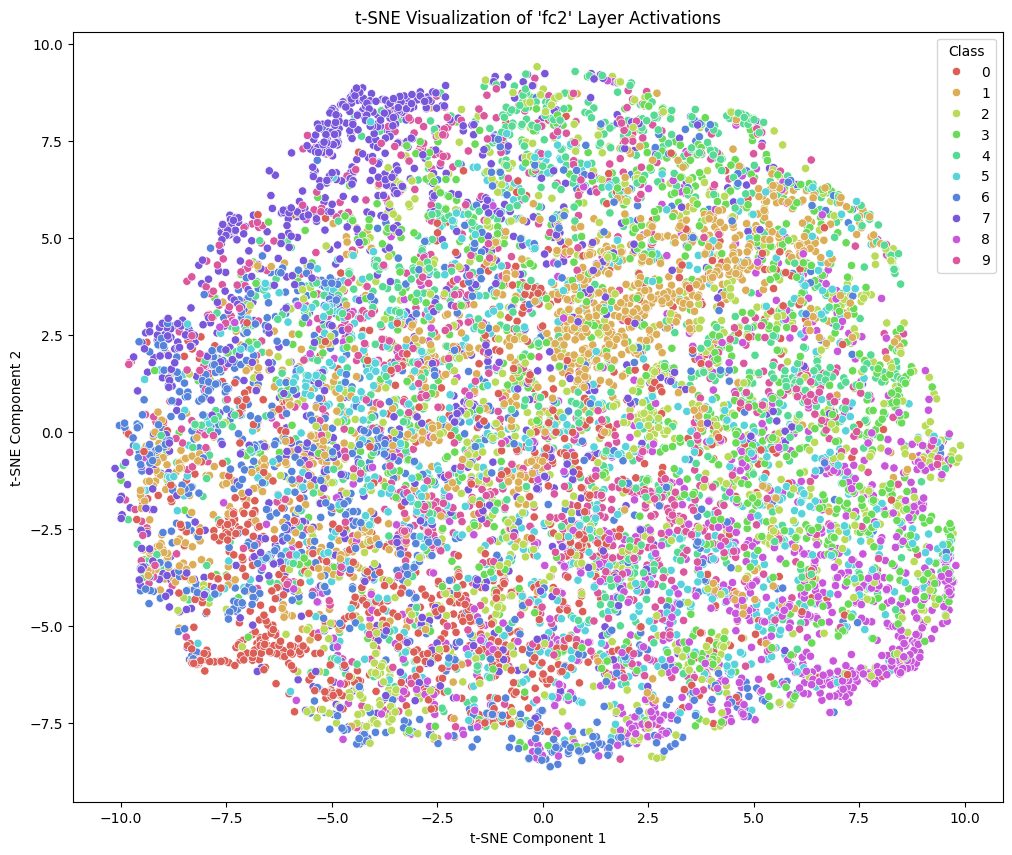

In [18]:
untrained_model = MLP()
untrained_model.plot_tsne(test_loader, device)

Accuracy of the model on the 10000 test images: 10.63%
              precision    recall  f1-score   support

 T-shirt/top       0.00      0.00      0.00      1000
     Trouser       0.00      0.00      0.00      1000
    Pullover       0.00      0.00      0.00      1000
       Dress       0.19      0.81      0.31      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       0.04      0.09      0.06      1000
       Shirt       0.16      0.02      0.03      1000
     Sneaker       0.17      0.01      0.01      1000
         Bag       0.69      0.13      0.21      1000
  Ankle boot       0.00      0.00      0.00      1000

    accuracy                           0.11     10000
   macro avg       0.13      0.11      0.06     10000
weighted avg       0.13      0.11      0.06     10000



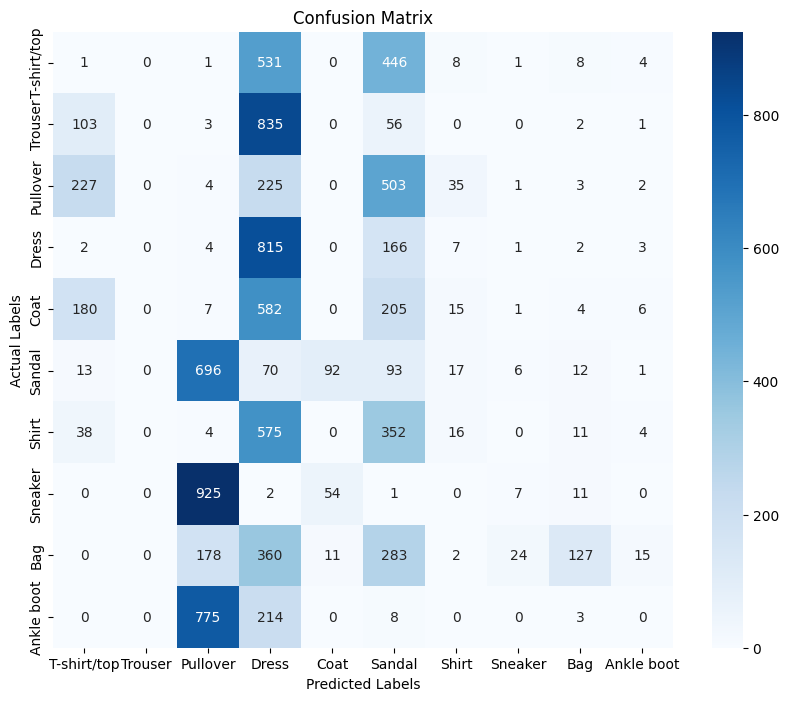

In [19]:
fashion_class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
accuracy = model_MLP.evaluate(test_loader_fashion, device, class_names=fashion_class_names)

In [20]:
#Training Fashion MNIST
model_fashion = MLP()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_fashion.parameters(), lr=0.001)

num_epochs = 10
model_fashion.fit(train_loader_fashion, criterion, optimizer, num_epochs, device)

Strating Training...
Epoch 1/10, Loss: 0.6857, Time: 1.81s
Epoch 2/10, Loss: 0.4651, Time: 1.81s
Epoch 3/10, Loss: 0.4252, Time: 1.99s
Epoch 4/10, Loss: 0.4025, Time: 2.03s
Epoch 5/10, Loss: 0.3863, Time: 1.77s
Epoch 6/10, Loss: 0.3683, Time: 1.78s
Epoch 7/10, Loss: 0.3555, Time: 1.80s
Epoch 8/10, Loss: 0.3445, Time: 1.77s
Epoch 9/10, Loss: 0.3340, Time: 1.79s
Epoch 10/10, Loss: 0.3257, Time: 2.22s
Finished Training!


Accuracy of the model on the 10000 test images: 86.48%
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.83      0.83      1000
     Trouser       0.98      0.96      0.97      1000
    Pullover       0.82      0.68      0.75      1000
       Dress       0.83      0.90      0.87      1000
        Coat       0.73      0.83      0.77      1000
      Sandal       0.97      0.93      0.95      1000
       Shirt       0.69      0.65      0.67      1000
     Sneaker       0.94      0.93      0.93      1000
         Bag       0.96      0.96      0.96      1000
  Ankle boot       0.92      0.97      0.95      1000

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000



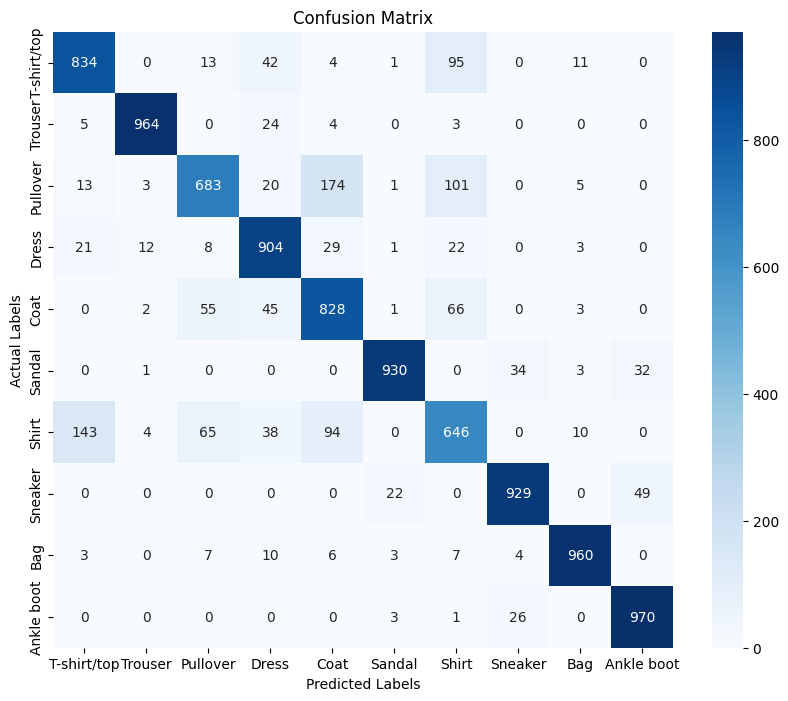

In [21]:
fashion_class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
accuracy = model_fashion.evaluate(test_loader_fashion, device, class_names=fashion_class_names)

Generating t-SNE plot for fc2 activations...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


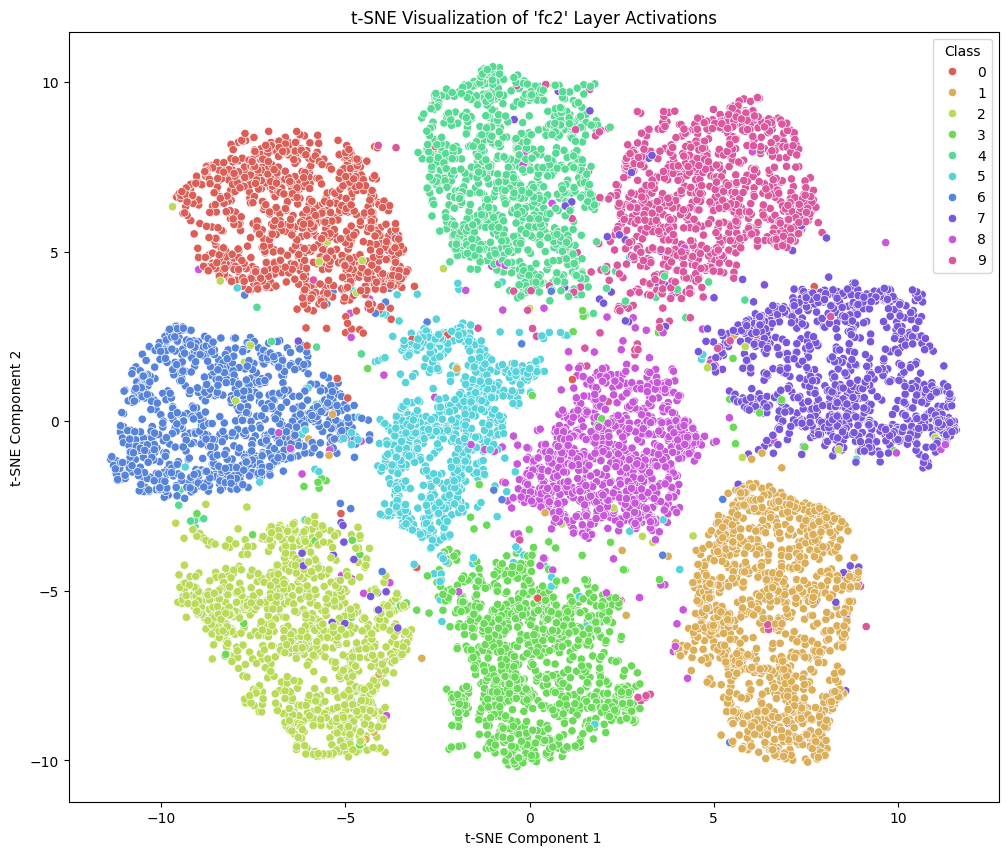

Generating t-SNE plot for fc2 activations...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


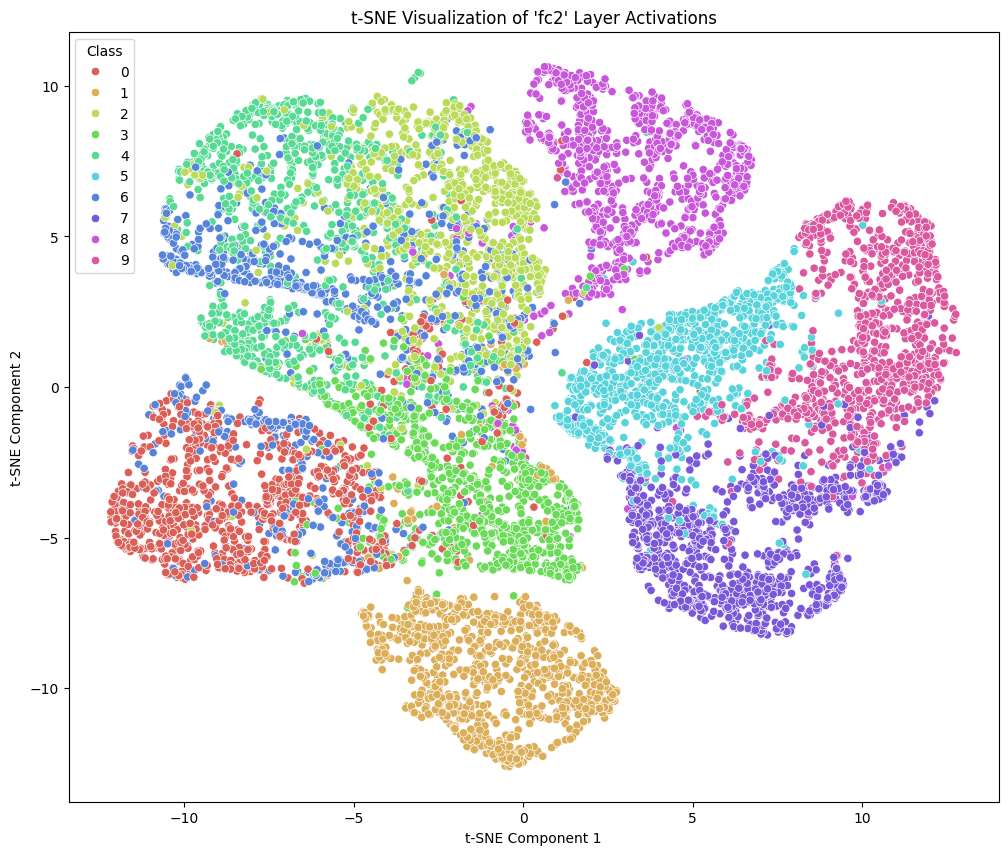

In [22]:
model_MLP.plot_tsne(test_loader, device)
model_fashion.plot_tsne(test_loader_fashion, device)

#### We can see that in MNIST, the clusters are well seperated an clean. This means our model can rightly classify the digits.

#### But in the case of Fashion MNIST dataset, while come clusters are clean and well seperated, other overlapp heavily (T-Shirt, Pullover etc etc). This means that our model is confused on similar items.

#### The plots clearly show that Fashion MNIST is a much harder problem than MNIST because its classes are visually very similar.

## CNN

In [23]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()
        # 1 input channel, 32 output channel, 3x3 kernel, 1 stride, 1 padding
        self.conv1 = nn.Conv2d(1,32,3,1,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        #32 channels * 14x14 features
        self.fc1 = nn.Linear(32*14*14,128)
        self.fc2 = nn.Linear(128,10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x))) #shape -> [N,32,14,14]
        x = torch.flatten(x,1) #Shape -> [N,32*14*14]
        x = F.relu(self.fc1(x)) #Shape -> [N,128]
        x = self.fc2(x) #Shape -> [N,10]
        return x

    def fit(self, train_loader, criterion, optimizer, num_epochs, device):
        print("Starting Training...")
        self.to(device)

        for epoch in range(num_epochs):
            start_time = time.time()

            self.train()
            runn_loss = 0.0

            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = self(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                runn_loss+=loss.item()

            epoch_time = time.time()-start_time
            avg_loss = runn_loss/len(train_loader)
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

        print("Finished Training!!")

    def evaluate(self, test_loader, device, class_names=None):
        self.to(device)
        self.eval()
        correct=0
        total=0
        all_labels = []
        all_preds = []

        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = self(inputs)
                # Class with highes score
                _, predicted = torch.max(outputs.data, 1)
                total+=labels.size(0)
                correct+=(predicted==labels).sum().item()
                all_labels.extend(labels.cpu().numpy())
                all_preds.extend(predicted.cpu().numpy())

        accuracy = 100*correct/total
        report = classification_report(all_labels, all_preds, target_names = class_names)
        print(f"Accuracy of the model on the {total} test images: {accuracy:.2f}%")
        print("\nClassification Report:")
        print(report)

        cm = confusion_matrix(all_labels, all_preds)
        if class_names is None:
            tick_labels = sorted(list(np.unique(all_labels)))
        else:
            tick_labels = class_names

        plt.figure(figsize=(10,8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=tick_labels, yticklabels=tick_labels)
        plt.title("Confusion Matrix")
        plt.ylabel("Actual Label")
        plt.xlabel("Predicted Label")
        plt.show()

        return accuracy

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

x_train_tensor_CNN = torch.from_numpy(x_train).unsqueeze(1).float()
y_train_tensor_CNN = torch.from_numpy(y_train).long()
x_test_tensor_CNN = torch.from_numpy(x_test).unsqueeze(1).float()
y_test_tensor_CNN = torch.from_numpy(y_test).long()

print(f"Training data shape: {x_train_tensor_CNN.shape}")
print(f"Test data shape: {x_test_tensor_CNN.shape}")

batch_size = 64
train_dataset_CNN = TensorDataset(x_train_tensor_CNN, y_train_tensor_CNN)
train_loader_CNN = DataLoader(train_dataset_CNN, batch_size=batch_size, shuffle=True)

test_dataset_CNN = TensorDataset(x_test_tensor_CNN, y_test_tensor_CNN)
test_loader_CNN = DataLoader(test_dataset_CNN, batch_size=batch_size, shuffle=False)

Using device: cuda
Training data shape: torch.Size([60000, 1, 28, 28])
Test data shape: torch.Size([10000, 1, 28, 28])


In [25]:
model_CNN = CNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_CNN.parameters(), lr=0.001)

num_epochs = 5
model_CNN.fit(train_loader_CNN, criterion, optimizer, num_epochs, device)

Starting Training...
Epoch 1/5, Loss: 0.6563, Time: 2.75s
Epoch 2/5, Loss: 0.1132, Time: 2.08s
Epoch 3/5, Loss: 0.0713, Time: 2.20s
Epoch 4/5, Loss: 0.0503, Time: 2.37s
Epoch 5/5, Loss: 0.0461, Time: 2.06s
Finished Training!!


Accuracy of the model on the 10000 test images: 97.92%

Classification Report:
              precision    recall  f1-score   support

     digit 0       0.98      0.99      0.98       980
     digit 1       0.99      0.99      0.99      1135
     digit 2       0.98      0.98      0.98      1032
     digit 3       0.98      0.97      0.98      1010
     digit 4       0.98      0.98      0.98       982
     digit 5       0.96      0.99      0.97       892
     digit 6       0.99      0.98      0.99       958
     digit 7       0.99      0.97      0.98      1028
     digit 8       0.97      0.98      0.97       974
     digit 9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



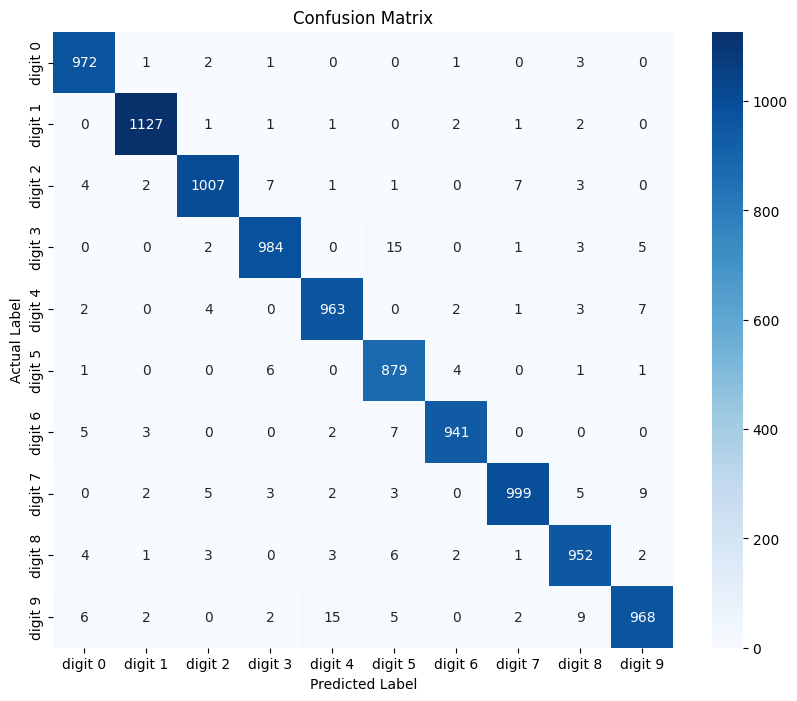

In [26]:
mnist_class_names = [f"digit {i}" for i in range(10)]
accuracy = model_CNN.evaluate(test_loader_CNN, device, class_names=mnist_class_names)

### Pre-Trained CNN Models


In [27]:
def get_pretrained_dataloaders(batch_size=64):
    """
    Creates DataLoaders for MNIST, adapted for pre-trained ImageNet models.
    """
    # Define the transforms
    # 1. Resize to 224x224
    # 2. Convert 1-channel Grayscale to 3-channel by repeating the channel
    # 3. Convert to Tensor (scales to [0, 1])
    # 4. Normalize with ImageNet stats (what the models were trained on)
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3), # 1 -> 3 channels
        transforms.ToTensor(),
        transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
    ])

    # Download and load the MNIST dataset
    print("Loading MNIST data with new transforms...")
    train_dataset = datasets.MNIST(root=".", train=True,
                                   download=True, transform=transform)
    test_dataset = datasets.MNIST(root=".", train=False,
                                  download=True, transform=transform)

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print("DataLoaders ready.")
    return train_loader, test_loader

In [28]:
def get_adapted_alexnet(device):
    """
    Loads a pre-trained AlexNet, freezes its layers,
    and replaces the final classifier for 10 classes.
    """
    print("Loading pre-trained AlexNet...")
    model = models.alexnet(pretrained=True)

    # Freeze all parameters in the feature-extraction layers
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of input features for the last layer
    num_ftrs = model.classifier[6].in_features

    # Replace the last layer with a new one for 10 classes
    model.classifier[6] = nn.Linear(num_ftrs, 10)

    return model.to(device)


In [29]:
def get_adapted_mobilenet(device):
    """
    Loads a pre-trained MobileNetV2, freezes its layers,
    and replaces the final classifier for 10 classes.
    """
    print("Loading pre-trained MobileNetV2...")
    model = models.mobilenet_v2(pretrained=True)

    # Freeze all parameters
    for param in model.parameters():
        param.requires_grad = False

    # Get the number of input features for the classifier
    num_ftrs = model.classifier[1].in_features

    # Replace the classifier
    model.classifier[1] = nn.Linear(num_ftrs, 10)

    return model.to(device)

In [30]:
def fit(model, train_loader, criterion, optimizer, num_epochs, device):
    print("Starting Training...")
    model.to(device)

    for epoch in range(num_epochs):
        start_time = time.time()
        model.train() # Set model to training mode
        runn_loss = 0.0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            runn_loss += loss.item()

        epoch_time = time.time() - start_time
        avg_loss = runn_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Time: {epoch_time:.2f}s")

    print("Finished Training!!")

In [31]:
def evaluate(model, test_loader, device, class_names=None):
    """
    Evaluates the model on the test set and prints a classification
    report and confusion matrix.
    """
    print("\nStarting Evaluation...")
    model.to(device)
    model.eval() # Set model to evaluation mode

    all_labels = []
    all_preds = []

    # No gradients needed for evaluation
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)

            # Get the predicted class (class with the highest score)
            _, predicted = torch.max(outputs.data, 1)

            # Store labels and predictions for later metrics
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    # --- Calculate and Print Metrics ---

    # 1. Overall Accuracy
    acc = accuracy_score(all_labels, all_preds)
    print(f"Accuracy on test set: {acc * 100:.2f}%")

    # 2. Classification Report
    if class_names is None:
        # Create default names '0', '1', '2', ...
        class_names = [str(i) for i in sorted(list(np.unique(all_labels)))]

    print("\nClassification Report:")
    report = classification_report(all_labels, all_preds, target_names=class_names)
    print(report)

    # 3. Confusion Matrix
    print("Plotting Confusion Matrix...")
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")
    plt.show()

    return acc


Using device: cuda
Loading MNIST data with new transforms...
DataLoaders ready.
Loading pre-trained AlexNet...
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 199MB/s]


Starting Training...
Epoch 1/2, Loss: 0.4216, Time: 116.05s
Epoch 2/2, Loss: 0.3422, Time: 117.76s
Finished Training!!

Starting Evaluation...
Accuracy on test set: 92.89%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       1.00      0.98      0.99      1135
           2       0.93      0.93      0.93      1032
           3       0.99      0.64      0.78      1010
           4       0.93      0.99      0.96       982
           5       0.69      0.98      0.81       892
           6       0.93      0.96      0.95       958
           7       0.98      0.93      0.96      1028
           8       0.98      0.93      0.96       974
           9       0.98      0.95      0.97      1009

    accuracy                           0.93     10000
   macro avg       0.94      0.93      0.93     10000
weighted avg       0.94      0.93      0.93     10000

Plotting Confusion Matrix...


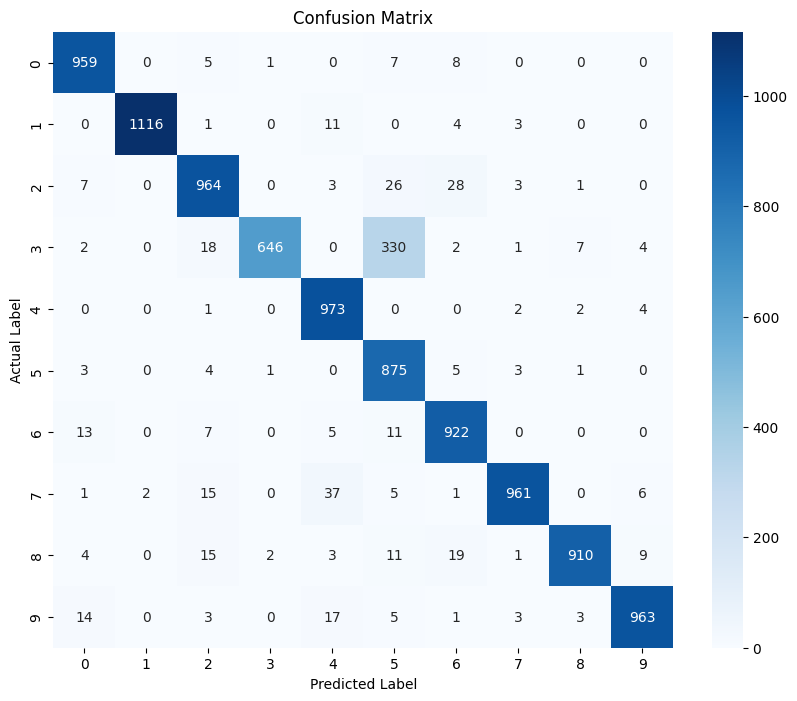

0.9289

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loader = get_pretrained_dataloaders(batch_size=32)

model = get_adapted_alexnet(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

fit(model, train_loader, criterion, optimizer, num_epochs=2, device=device)
evaluate(model, test_loader, device)

Loading pre-trained MobileNetV2...
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


Starting Training...
Epoch 1/2, Loss: 0.3447, Time: 158.77s
Epoch 2/2, Loss: 0.2116, Time: 150.97s
Finished Training!!

Starting Evaluation...
Accuracy on test set: 95.70%

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       980
           1       0.99      0.99      0.99      1135
           2       0.95      0.93      0.94      1032
           3       0.92      0.98      0.95      1010
           4       0.93      0.98      0.96       982
           5       0.98      0.91      0.94       892
           6       0.98      0.94      0.96       958
           7       0.96      0.95      0.96      1028
           8       0.93      0.97      0.95       974
           9       0.96      0.94      0.95      1009

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000

Plotting Confusion Matrix...


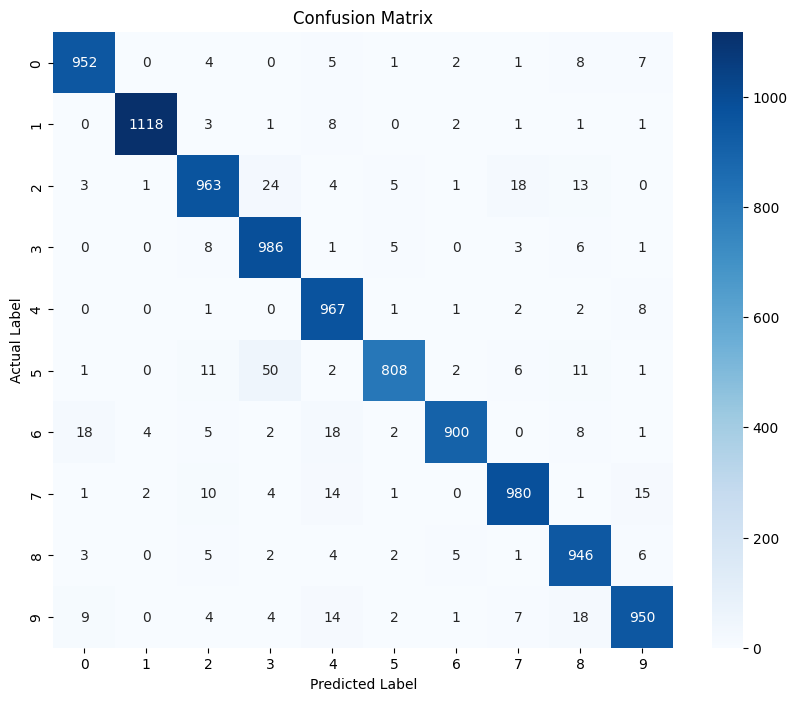

0.957

In [33]:
model_2 = get_adapted_mobilenet(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model_2.parameters(), lr=0.001)

fit(model_2, train_loader, criterion, optimizer, num_epochs=2, device=device)
evaluate(model_2, test_loader, device)

| Model | Accuracy | Macro Avg F1-Score | Weighted Avg F1-Score | Model Size (Parameters) |
| :--- | :--- | :--- | :--- | :--- |
| **Our CNN** | **97.92%** | **0.98** | **0.98** | **~804,554** |
| MobileNetV2 | 95.70% | 0.96 | 0.96 | ~3,500,000 |
| AlexNet | 92.89% | 0.93 | 0.93 | ~60,000,000 |